# imports

In [31]:
import os, sys
# os.chdir("/home/kirschkobold/LIFEsim")
# sys.path.insert(0, os.getcwd())

In [32]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from tqdm import tqdm

import lifesim
from spectres import spectres

from lifesim.util.radiation import black_body

In [33]:
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# LIFEsim setup

In [34]:
bus = lifesim.Bus()

bus.data.options.set_scenario('baseline')

bus.data.options.set_manual(output_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/yield_testing_old/')
bus.data.options.set_manual(output_filename='test_run_withinstrument')

In [35]:
option_name = 'ota_temperature'
option_value = float(48)

In [36]:
bus.data.options.set_manual(**{option_name: option_value})

In [37]:
bus.data.options.thermal['ota_temperature']

48.0

## download ppop catalog

In [38]:
bus.data.catalog_from_ppop(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/ppop_catalog/ppop_catalog.txt', overwrite=True)
bus.data.catalog_remove_distance(stype='A', mode='larger', dist=0.)  # remove all A stars
bus.data.catalog_remove_distance(stype='M', mode='larger', dist=10.)  # remove M stars > 10pc to
# speed up calculation

Processed line 33048 of 33048


## create instrument

In [39]:
instrument = lifesim.Instrument(name='inst')
bus.add_module(instrument)

transm = lifesim.TransmissionMap(name='transm')
bus.add_module(transm)

exo = lifesim.PhotonNoiseExozodi(name='exo')
bus.add_module(exo)
local = lifesim.PhotonNoiseLocalzodi(name='local')
bus.add_module(local)
star = lifesim.PhotonNoiseStar(name='star')
bus.add_module(star)
mirror = lifesim.PhotonNoiseThermal(name='mirror')
bus.add_module(mirror)
# darkcurrent = lifesim.ElectronNoiseDarkCurrent(name='darkcurrent')
# bus.add_module(darkcurrent)


# connect all modules
bus.connect(('inst', 'transm'))
bus.connect(('inst', 'exo'))
bus.connect(('inst', 'local'))
bus.connect(('inst', 'star'))
bus.connect(('inst', 'mirror'))
# bus.connect(('inst', 'darkcurrent'))


bus.connect(('star', 'transm'))

# instrument.apply_options()

## create optimizer

In [40]:
# ---------- Creating the Optimizer ----------
# After every planet is given an SNR, we want to distribute the time available in the search phase
# such that we maximize the number of detections.

# optimizing the result
opt = lifesim.Optimizer(name='opt')
bus.add_module(opt)
ahgs = lifesim.AhgsModule(name='ahgs')
bus.add_module(ahgs)

bus.connect(('transm', 'opt'))
bus.connect(('inst', 'opt'))
bus.connect(('opt', 'ahgs'))

# run simulation

In [41]:
instrument.get_snr()

100%|██████████| 345/345 [00:16<00:00, 21.28it/s]


In [42]:
opt.ahgs()

Number of planets detected for each experiment:
F: 1.0  G: 2.7  K: 8.4  M: 13.3  -  (2.0 / 2.0) yrs observed


In [43]:
# save the results
bus.save()

Saving database and config files...
Catalog saved
[Done]


# reading results

In [46]:
bus_read = lifesim.Bus()
bus_read.build_from_config('/home/kirschkobold/documents/life_internship/LIFEsim_yields/yield_testing_old/test_run.yaml')
bus_read.data.import_catalog(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/yield_testing_old/test_run_catalog.hdf5')

ValueError: Option name(s) found in multiple categories: 'habitable' in categories: optimization, models

# interpretung results

In [47]:
mask_mtype = bus.data.catalog.stype == 'M'
mask = np.logical_and.reduce((bus.data.catalog.detected, bus.data.catalog.habitable, mask_mtype))
result_number = mask.sum()/10
print(result_number)

12.0


In [48]:
print(bus.data.catalog['habitable'].value_counts())
print(bus.data.catalog['detected'].value_counts())

habitable
False    6662
True     1115
Name: count, dtype: int64
detected
False    6460
True     1317
Name: count, dtype: int64


# testing snr

In [49]:
mask_habitable = bus.data.catalog.habitable
mask_detected = bus.data.catalog.detected

In [ ]:
recompute = False
if recompute:
    min = 30
    max = 55
    temperatures = np.linspace(min, max, max-min+1)
    for temp in temperatures:
        bus.data.options.set_manual(primary_temp=temp)
        print(f"Computing SNR for mirror temperature {temp} K")
        instrument.get_snr()
        opt.ahgs()
        bus.data.catalog.to_csv(f'/home/kirschkobold/LIFEsim/kira_testing/yield/mirrortemps/catalog_mirror_{temp:.0f}K.txt')
        print(f"Saved catalog for mirror temperature {temp:.0f} K")

: 

In [ ]:
min = 30
max = 55
temperatures = np.linspace(min, max, max-min+1)

: 

In [ ]:
folder = "/home/kirschkobold/LIFEsim/kira_testing/yield/mirrortemps"
dfs = {}
for fp in sorted(glob.glob(os.path.join(folder, "*"))):
    name = os.path.splitext(os.path.basename(fp))[0]           # e.g. "catalog_mirror_30K"
    dfs[name] = pd.read_csv(fp, comment='#', sep=None, engine='python')
for key, df in dfs.items():
    var = re.sub(r'\W+', '_', key)
    globals()[var] = df

: 

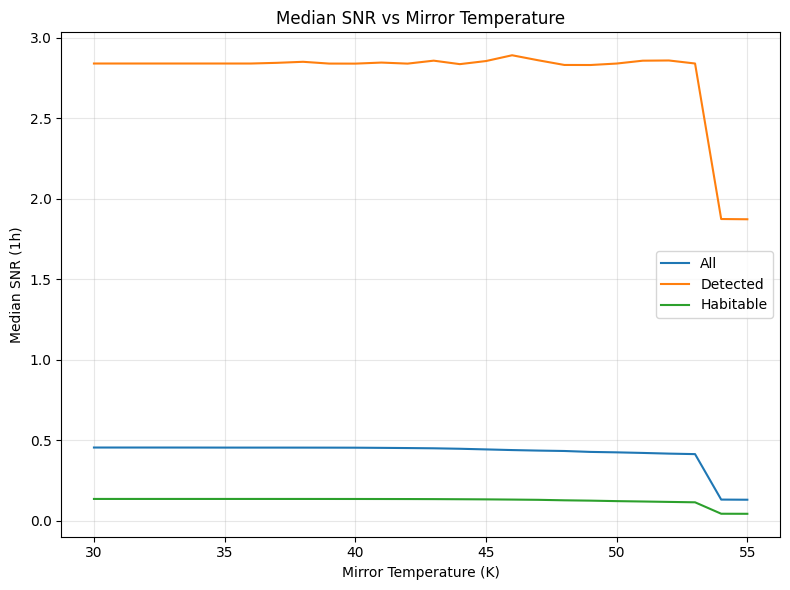

: 

In [ ]:
# Calculate median for each category
all_vals = [dfs[key]['snr_1h'].median() for key in sorted(dfs.keys())]
detected_vals = [dfs[key][dfs[key]['detected']]['snr_1h'].median() for key in sorted(dfs.keys())]
habitable_vals = [dfs[key][dfs[key]['habitable']]['snr_1h'].median() for key in sorted(dfs.keys())]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_vals, color='C0', label='All')
ax.plot(temperatures, detected_vals, color='C1', label='Detected')
ax.plot(temperatures, habitable_vals, color='C2', label='Habitable')
ax.set_xlabel('Mirror Temperature (K)')
ax.set_ylabel('Median SNR (1h)')
ax.set_title('Median SNR vs Mirror Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

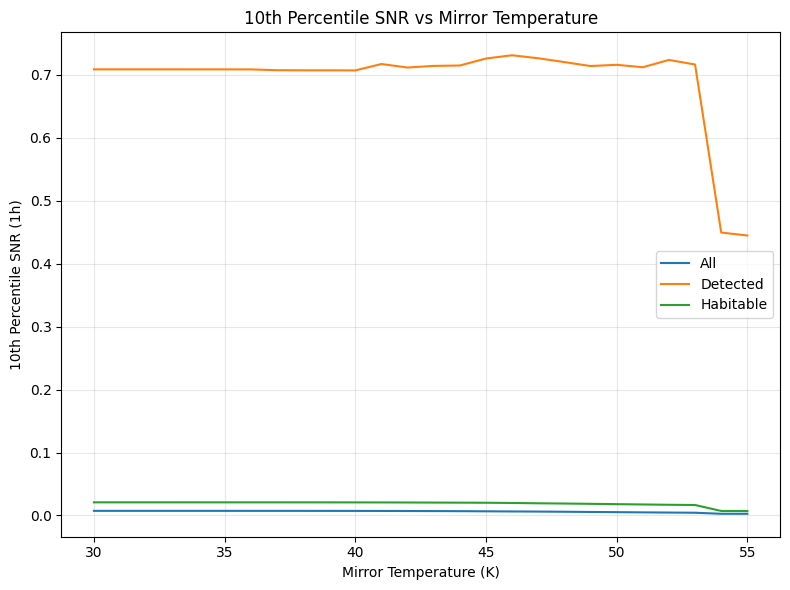

: 

In [ ]:
# Calculate 10th percentile for each category
all_vals = [dfs[key]['snr_1h'].quantile(0.1) for key in sorted(dfs.keys())]
detected_vals = [dfs[key][dfs[key]['detected']]['snr_1h'].quantile(0.1) for key in sorted(dfs.keys())]
habitable_vals = [dfs[key][dfs[key]['habitable']]['snr_1h'].quantile(0.1) for key in sorted(dfs.keys())]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_vals, color='C0', label='All')
ax.plot(temperatures, detected_vals, color='C1', label='Detected')
ax.plot(temperatures, habitable_vals, color='C2', label='Habitable')
ax.set_xlabel('Mirror Temperature (K)')
ax.set_ylabel('10th Percentile SNR (1h)')
ax.set_title('10th Percentile SNR vs Mirror Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

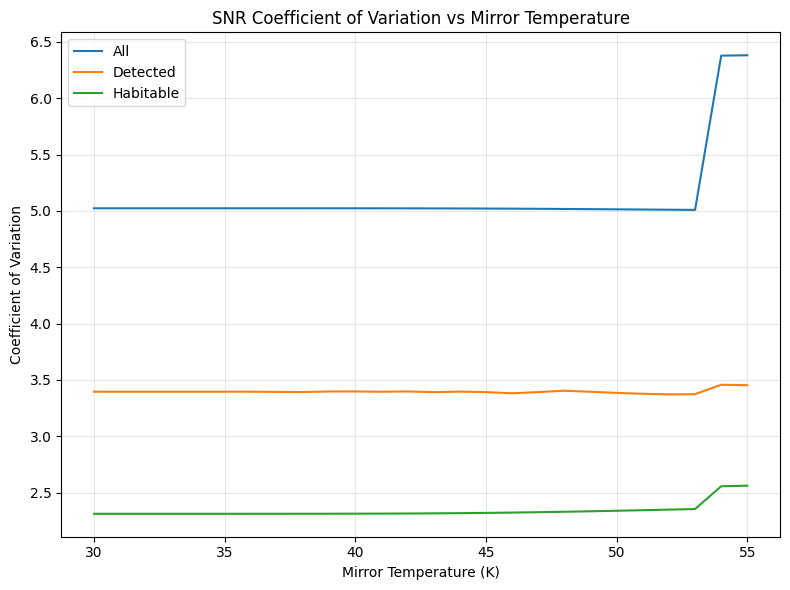

: 

In [ ]:
# Calculate coefficient of variation for each category
all_cv = []
detected_cv = []
habitable_cv = []

for key in sorted(dfs.keys()):
    df = dfs[key]
    
    # All
    all_mean = df['snr_1h'].mean()
    all_std = df['snr_1h'].std()
    all_cv.append(all_std / all_mean if all_mean != 0 else 0)
    
    # Detected
    detected_df = df[df['detected']]
    detected_mean = detected_df['snr_1h'].mean()
    detected_std = detected_df['snr_1h'].std()
    detected_cv.append(detected_std / detected_mean if detected_mean != 0 else 0)
    
    # Habitable
    habitable_df = df[df['habitable']]
    habitable_mean = habitable_df['snr_1h'].mean()
    habitable_std = habitable_df['snr_1h'].std()
    habitable_cv.append(habitable_std / habitable_mean if habitable_mean != 0 else 0)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_cv, color='C0', label='All')
ax.plot(temperatures, detected_cv, color='C1', label='Detected')
ax.plot(temperatures, habitable_cv, color='C2', label='Habitable')
ax.set_xlabel('Mirror Temperature (K)')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('SNR Coefficient of Variation vs Mirror Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

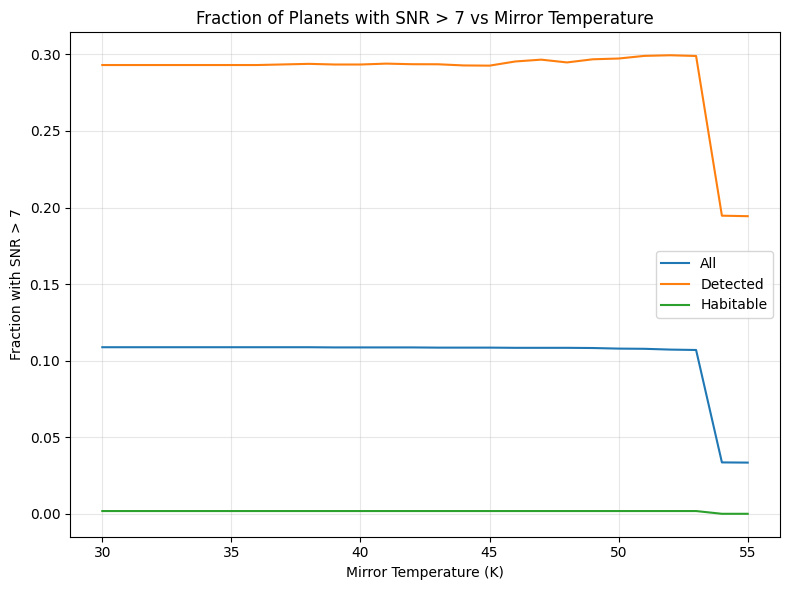

: 

In [ ]:
# Calculate fraction of planets with SNR > 7 for each category
all_frac = []
detected_frac = []
habitable_frac = []

for key in sorted(dfs.keys()):
    df = dfs[key]
    
    # All
    all_total = len(df)
    all_above = (df['snr_1h'] > 7).sum()
    all_frac.append(all_above / all_total if all_total > 0 else 0)
    
    # Detected
    detected_df = df[df['detected']]
    detected_total = len(detected_df)
    detected_above = (detected_df['snr_1h'] > 7).sum()
    detected_frac.append(detected_above / detected_total if detected_total > 0 else 0)
    
    # Habitable
    habitable_df = df[df['habitable']]
    habitable_total = len(habitable_df)
    habitable_above = (habitable_df['snr_1h'] > 7).sum()
    habitable_frac.append(habitable_above / habitable_total if habitable_total > 0 else 0)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_frac, color='C0', label='All')
ax.plot(temperatures, detected_frac, color='C1', label='Detected')
ax.plot(temperatures, habitable_frac, color='C2', label='Habitable')
ax.set_xlabel('Mirror Temperature (K)')
ax.set_ylabel('Fraction with SNR > 7')
ax.set_title('Fraction of Planets with SNR > 7 vs Mirror Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

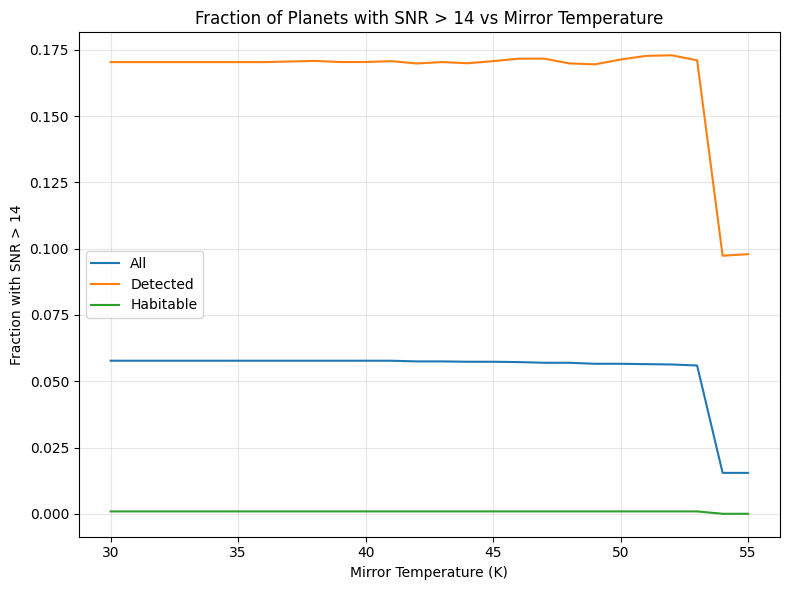

: 

In [ ]:
# Calculate fraction of planets with SNR > 7 for each category
all_frac = []
detected_frac = []
habitable_frac = []

for key in sorted(dfs.keys()):
    df = dfs[key]
    
    # All
    all_total = len(df)
    all_above = (df['snr_1h'] > 14).sum()
    all_frac.append(all_above / all_total if all_total > 0 else 0)
    
    # Detected
    detected_df = df[df['detected']]
    detected_total = len(detected_df)
    detected_above = (detected_df['snr_1h'] > 14).sum()
    detected_frac.append(detected_above / detected_total if detected_total > 0 else 0)
    
    # Habitable
    habitable_df = df[df['habitable']]
    habitable_total = len(habitable_df)
    habitable_above = (habitable_df['snr_1h'] > 14).sum()
    habitable_frac.append(habitable_above / habitable_total if habitable_total > 0 else 0)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_frac, color='C0', label='All')
ax.plot(temperatures, detected_frac, color='C1', label='Detected')
ax.plot(temperatures, habitable_frac, color='C2', label='Habitable')
ax.set_xlabel('Mirror Temperature (K)')
ax.set_ylabel('Fraction with SNR > 14')
ax.set_title('Fraction of Planets with SNR > 14 vs Mirror Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

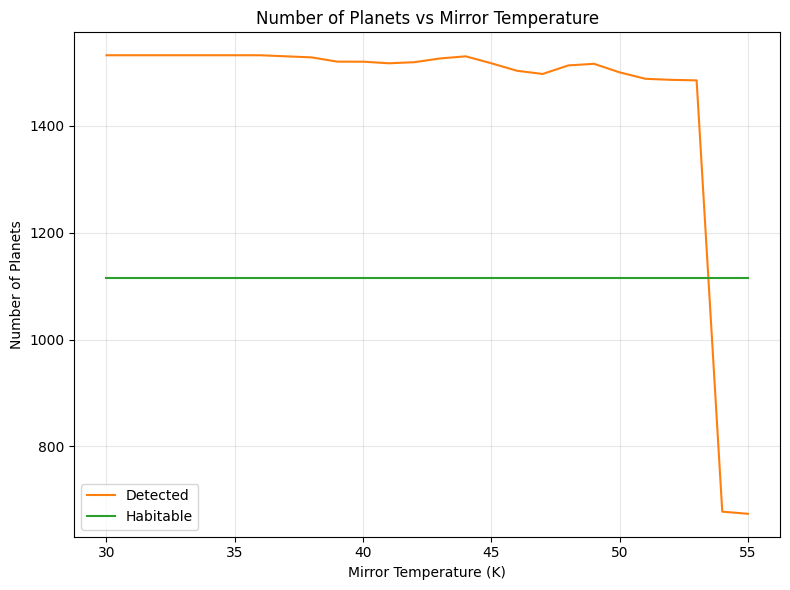

: 

In [ ]:
# Calculate absolute number of detected and habitable planets for each category
all_counts = []
detected_counts = []
habitable_counts = []

for key in sorted(dfs.keys()):
    df = dfs[key]
    
    # All planets
    all_counts.append(len(df))
    
    # Detected planets
    detected_counts.append((df['detected']).sum())
    
    # Habitable planets
    habitable_counts.append((df['habitable']).sum())

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(temperatures, all_counts, color='C0', label='All')
ax.plot(temperatures, detected_counts, color='C1', label='Detected')
ax.plot(temperatures, habitable_counts, color='C2', label='Habitable')
ax.set_xlabel('Mirror Temperature (K)')
ax.set_ylabel('Number of Planets')
ax.set_title('Number of Planets vs Mirror Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
recompute = False
if recompute:
    min = 15
    max = 19
    temperatures = np.linspace(min, max, max-min+1)
    for temp in temperatures:
        bus.data.options.set_manual(primary_temp=48)
        bus.data.options.set_manual(d_temp=temp)
        print(f"Computing SNR for detector temperature {temp} K")
        instrument.get_snr()
        opt.ahgs()
        bus.data.catalog.to_csv(f'/home/kirschkobold/LIFEsim/kira_testing/yield/detectortemps/catalog_detector_{temp:.0f}K.txt')
        print(f"Saved catalog for detector temperature {temp:.0f} K")

: 

In [ ]:
folder = "/home/kirschkobold/LIFEsim/kira_testing/yield/detectortemps"
dfs_d = {}
for fp in sorted(glob.glob(os.path.join(folder, "*"))):
    name = os.path.splitext(os.path.basename(fp))[0]           # e.g. "catalog_detector_30K"
    dfs_d[name] = pd.read_csv(fp, comment='#', sep=None, engine='python')
for key, df in dfs_d.items():
    var = re.sub(r'\W+', '_', key)
    globals()[var] = df

: 

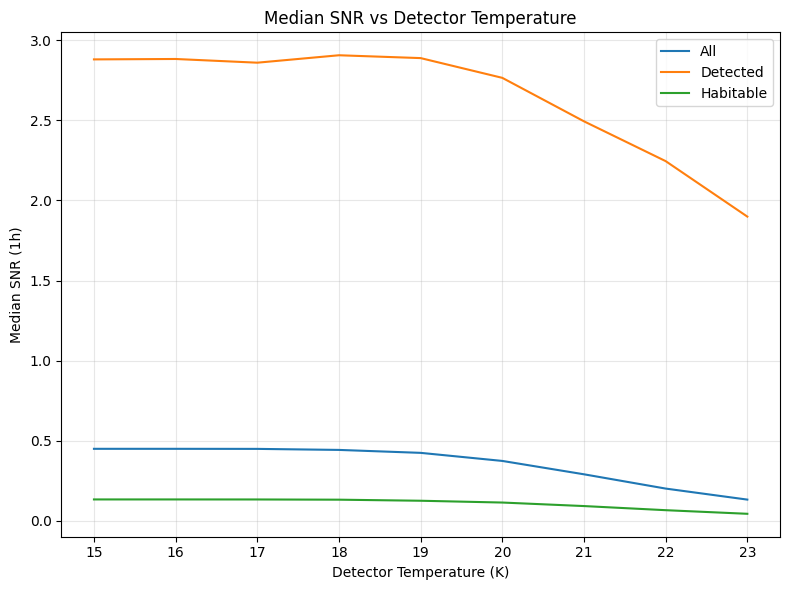

: 

In [ ]:
temperatures = np.linspace(15, 23, 9)

# Calculate median for each category
all_vals = [dfs_d[key]['snr_1h'].median() for key in sorted(dfs_d.keys())]
detected_vals = [dfs_d[key][dfs_d[key]['detected']]['snr_1h'].median() for key in sorted(dfs_d.keys())]
habitable_vals = [dfs_d[key][dfs_d[key]['habitable']]['snr_1h'].median() for key in sorted(dfs_d.keys())]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_vals, color='C0', label='All')
ax.plot(temperatures, detected_vals, color='C1', label='Detected')
ax.plot(temperatures, habitable_vals, color='C2', label='Habitable')
ax.set_xlabel('Detector Temperature (K)')
ax.set_ylabel('Median SNR (1h)')
ax.set_title('Median SNR vs Detector Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

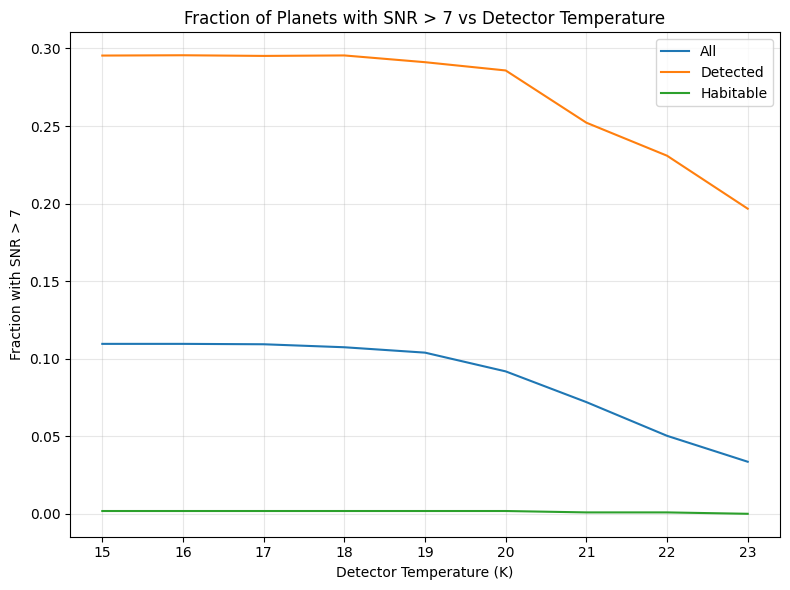

: 

In [ ]:
# Calculate fraction of planets with SNR > 7 for each category
all_frac = []
detected_frac = []
habitable_frac = []

for key in sorted(dfs_d.keys()):
    df = dfs_d[key]
    
    # All
    all_total = len(df)
    all_above = (df['snr_1h'] > 7).sum()
    all_frac.append(all_above / all_total if all_total > 0 else 0)
    
    # Detected
    detected_df = df[df['detected']]
    detected_total = len(detected_df)
    detected_above = (detected_df['snr_1h'] > 7).sum()
    detected_frac.append(detected_above / detected_total if detected_total > 0 else 0)
    
    # Habitable
    habitable_df = df[df['habitable']]
    habitable_total = len(habitable_df)
    habitable_above = (habitable_df['snr_1h'] > 7).sum()
    habitable_frac.append(habitable_above / habitable_total if habitable_total > 0 else 0)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(temperatures, all_frac, color='C0', label='All')
ax.plot(temperatures, detected_frac, color='C1', label='Detected')
ax.plot(temperatures, habitable_frac, color='C2', label='Habitable')
ax.set_xlabel('Detector Temperature (K)')
ax.set_ylabel('Fraction with SNR > 7')
ax.set_title('Fraction of Planets with SNR > 7 vs Detector Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

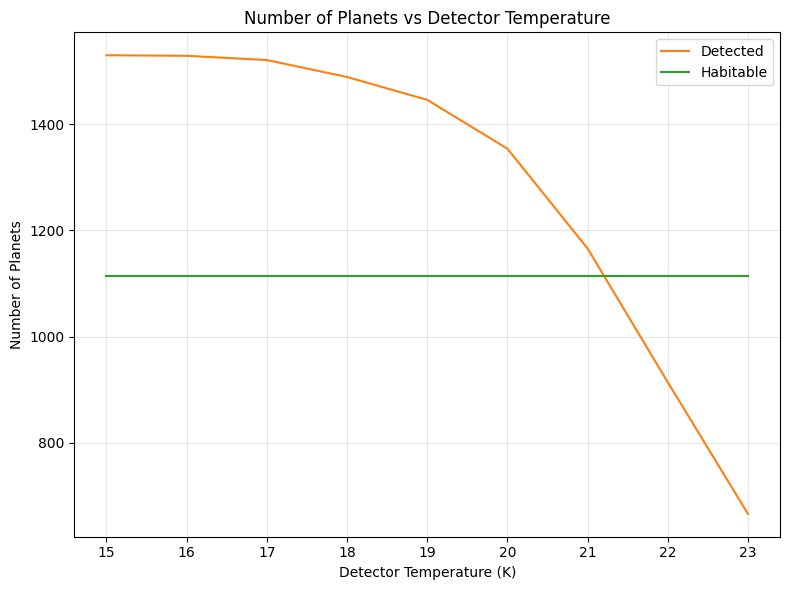

: 

In [ ]:
# Calculate absolute number of detected and habitable planets for each category
all_counts = []
detected_counts = []
habitable_counts = []

for key in sorted(dfs_d.keys()):
    df = dfs_d[key]
    
    # All planets
    all_counts.append(len(df))
    
    # Detected planets
    detected_counts.append((df['detected']).sum())
    
    # Habitable planets
    habitable_counts.append((df['habitable']).sum())

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(temperatures, all_counts, color='C0', label='All')
ax.plot(temperatures, detected_counts, color='C1', label='Detected')
ax.plot(temperatures, habitable_counts, color='C2', label='Habitable')
ax.set_xlabel('Detector Temperature (K)')
ax.set_ylabel('Number of Planets')
ax.set_title('Number of Planets vs Detector Temperature')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()